In [1]:
import numpy as np
import pandas as pd
from ase.visualize import view
from ase.io import read, write
import matplotlib.pyplot as plt
import scienceplots
from funciones import get_molecules
from funciones import get_data

We read all the steps of the third file of the simulations

In [2]:
all_atoms = read("/home/hernan-barquero/Desktop/Codigos/PhiS/Computational_Material_Science/carbon_nanoscrolls/t10_interface/last_converged/pw.out.25986", index ='1:')

#write("anima.mp4",all_atoms[:50], interval = 10)

In [3]:
all_atoms[-1].symbols.indices()

{'Cl': array([  0,   1,   2,   4,   5,   6,   8,   9,  10,  12,  13,  14,  16,
         17,  18,  20,  21,  22,  24,  25,  26,  28,  29,  30,  32,  33,
         34,  36,  37,  38,  40,  41,  42,  44,  45,  46,  48,  49,  50,
         71,  91, 111, 131, 151, 171, 191, 211, 231, 251, 271, 291, 311,
        331, 351, 371, 391]),
 'Al': array([ 3,  7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51]),
 'N': array([ 52,  53,  72,  73,  92,  93, 112, 113, 132, 133, 152, 153, 172,
        173, 192, 193, 212, 213, 232, 233, 252, 253, 272, 273, 292, 293,
        312, 313, 332, 333, 352, 353, 372, 373]),
 'C': array([ 54,  55,  56,  57,  58,  59,  74,  75,  76,  77,  78,  79,  94,
         95,  96,  97,  98,  99, 114, 115, 116, 117, 118, 119, 134, 135,
        136, 137, 138, 139, 154, 155, 156, 157, 158, 159, 174, 175, 176,
        177, 178, 179, 194, 195, 196, 197, 198, 199, 214, 215, 216, 217,
        218, 219, 234, 235, 236, 237, 238, 239, 254, 255, 256, 257, 258,
        259, 274, 275, 276, 277, 

In [4]:
print("Number of AlCl3 and EMiC")
display(len(all_atoms[-1].symbols.indices()['Al']),int(len(all_atoms[-1].symbols.indices()['N'])/2))


Number of AlCl3 and EMiC


13

17

In [5]:
view(all_atoms)

<Popen: returncode: None args: ['/home/hernan-barquero/anaconda3/envs/genera...>

In [6]:
all_carbons = [frame[[atom.index for atom in frame if atom.symbol == "C"]] for frame in all_atoms]
view(all_carbons)

<Popen: returncode: None args: ['/home/hernan-barquero/anaconda3/envs/genera...>

In [7]:
moleculas = get_molecules(["alcl3_opt.xyz","1-Ethyl-3-methylimidazolium_chloride_opt.xyz"], "/home/hernan-barquero/Desktop/Codigos/PhiS/Computational_Material_Science/carbon_nanoscrolls/t10_interface/last_converged/pw.out.25986")
len(moleculas)

30

In [8]:
al_idx_from_alcl3 = all_atoms[0].symbols.indices()['Al']
al_idx_from_alcl3

array([ 3,  7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51])

In [9]:
n_EMiC = 17


cl_idx_from_EMiC = np.zeros(shape=(n_EMiC),dtype=int)
c_idx_from_EMiC = np.zeros(shape=(n_EMiC*6),dtype=int)


cl_iter = 0
c_iter = 0
for molecula in moleculas:
	if molecula.nombre == 'NNCCCCCCHHHHHHHHHHHCl':
		for atomo in molecula.atomos:
			if atomo.simbolo == 'Cl':
				cl_idx_from_EMiC[cl_iter] = atomo.idx
				cl_iter +=1
			elif atomo.simbolo == "C":
				c_idx_from_EMiC[c_iter] = atomo.idx 
				c_iter +=1

display(cl_idx_from_EMiC,c_idx_from_EMiC)

array([ 71,  91, 111, 131, 151, 171, 191, 211, 231, 251, 271, 291, 311,
       331, 351, 371, 391])

array([ 54,  55,  56,  57,  58,  59,  74,  75,  76,  77,  78,  79,  94,
        95,  96,  97,  98,  99, 114, 115, 116, 117, 118, 119, 134, 135,
       136, 137, 138, 139, 154, 155, 156, 157, 158, 159, 174, 175, 176,
       177, 178, 179, 194, 195, 196, 197, 198, 199, 214, 215, 216, 217,
       218, 219, 234, 235, 236, 237, 238, 239, 254, 255, 256, 257, 258,
       259, 274, 275, 276, 277, 278, 279, 294, 295, 296, 297, 298, 299,
       314, 315, 316, 317, 318, 319, 334, 335, 336, 337, 338, 339, 354,
       355, 356, 357, 358, 359, 374, 375, 376, 377, 378, 379])

Now, we want to get the index of the carbons of the nanoscroll

In [10]:
mask = np.isin(element=all_atoms[0].symbols.indices()['C'], test_elements=c_idx_from_EMiC, invert=True)


c_idx_nanoscroll = all_atoms[0].symbols.indices()['C'][mask]
c_idx_nanoscroll

array([392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404,
       405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417,
       418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430,
       431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443,
       444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456,
       457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469,
       470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482,
       483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495,
       496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508,
       509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521,
       522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534,
       535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547,
       548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560,
       561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 57

In [11]:
""" df = get_data(["alcl3_opt.xyz","1-Ethyl-3-methylimidazolium_chloride_opt.xyz"], "/home/hernan-barquero/Desktop/Codigos/PhiS/Computational_Material_Science/carbon_nanoscrolls/t10_interface/last_converged/electrolyte.traj")
df """

' df = get_data(["alcl3_opt.xyz","1-Ethyl-3-methylimidazolium_chloride_opt.xyz"], "/home/hernan-barquero/Desktop/Codigos/PhiS/Computational_Material_Science/carbon_nanoscrolls/t10_interface/last_converged/electrolyte.traj")\ndf '

In [12]:
""" df_moles = df[[c for c in df.columns if "ClClClAl" in c]]
df_moles """

' df_moles = df[[c for c in df.columns if "ClClClAl" in c]]\ndf_moles '

In [13]:
""" new_cols = {}
n = 3  

for i in range(0, len(df_moles.columns), n):
    grupo = df_moles.iloc[:, i:i+n]          # selecciona columnas i, i+1, i+2
    new_col_name = f"ClClClAl_r_{i//n + 1}" # nombre de la nueva columna
    new_cols[new_col_name] = np.linalg.norm(grupo.values, axis=1)

df_norms = pd.DataFrame(new_cols)
df_norms """

' new_cols = {}\nn = 3  \n\nfor i in range(0, len(df_moles.columns), n):\n    grupo = df_moles.iloc[:, i:i+n]          # selecciona columnas i, i+1, i+2\n    new_col_name = f"ClClClAl_r_{i//n + 1}" # nombre de la nueva columna\n    new_cols[new_col_name] = np.linalg.norm(grupo.values, axis=1)\n\ndf_norms = pd.DataFrame(new_cols)\ndf_norms '

In [14]:
# df_norms.describe()

In [15]:
""" import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Configuración de la figura
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_norms.columns, df_norms.iloc[0].values)  # valores iniciales (fila 0)
ax.set_ylim(0, df_norms.values.max() + 2)           # ajustar límites del eje y
ax.set_title("Animación de barras por fila")
ax.set_ylabel("Posición radial")
plt.xticks(rotation=90)
# Función de actualización
def update(frame):
    for bar, val in zip(bars, df_norms.iloc[frame].values):
        bar.set_height(val)
    ax.set_xlabel(f"Iteracion {frame}")
    return bars

# Crear animación
anim = FuncAnimation(fig, update, frames=len(df_norms), interval=500, blit=False)


# Para guardar como mp4
anim.save("animacion_barras.mp4", writer="ffmpeg", fps=5) """

' import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom matplotlib.animation import FuncAnimation\n\n# Configuración de la figura\nfig, ax = plt.subplots(figsize=(8, 5))\nbars = ax.bar(df_norms.columns, df_norms.iloc[0].values)  # valores iniciales (fila 0)\nax.set_ylim(0, df_norms.values.max() + 2)           # ajustar límites del eje y\nax.set_title("Animación de barras por fila")\nax.set_ylabel("Posición radial")\nplt.xticks(rotation=90)\n# Función de actualización\ndef update(frame):\n    for bar, val in zip(bars, df_norms.iloc[frame].values):\n        bar.set_height(val)\n    ax.set_xlabel(f"Iteracion {frame}")\n    return bars\n\n# Crear animación\nanim = FuncAnimation(fig, update, frames=len(df_norms), interval=500, blit=False)\n\n\n# Para guardar como mp4\nanim.save("animacion_barras.mp4", writer="ffmpeg", fps=5) '

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
    ~~~~^^
  File "/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
    ~~~~~~~~^^
  File "/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/matplotlib/pyplot.py", line 614, in show
    return _get_backend_mod().show(*args, **kwargs)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
    ~~~~~~~^
        figure_manager.canvas.figure,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        metadata=_fetch_figure_metadata(figure_manager.canvas.figure)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^

Text(0.5, 0, 'r')

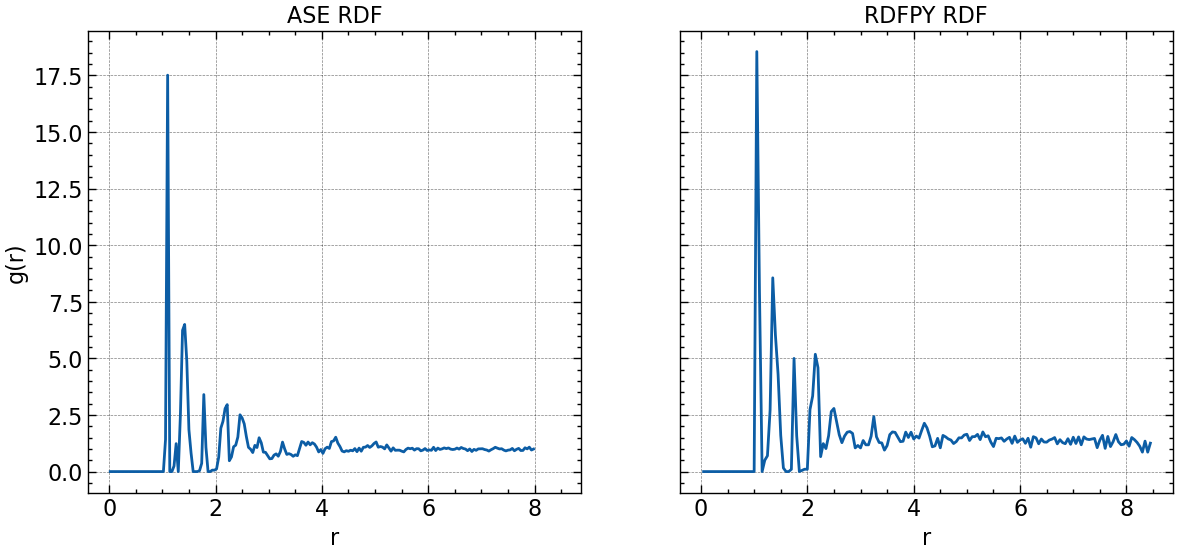

In [16]:
plt.style.use(['science','notebook','grid'])

fig, ax = plt.subplots(1,2, figsize = (14,6), sharex=True, sharey=True)

# Con ase

from ase.geometry.analysis import get_rdf

a = get_rdf(all_atoms[-1], 8,200)
ax[0].plot(a[1],a[0])
ax[0].set_title("ASE RDF")
ax[0].set_xlabel("r")
ax[0].set_ylabel("g(r)")


# Recomendado de Tomas
from rdfpy import rdf
gr, radii = rdf(all_atoms[-1].get_positions(), dr = 0.05)


ax[1].plot(radii, gr)
ax[1].set_title("RDFPY RDF")
ax[1].set_xlabel("r")


In [17]:
all_atoms[0][np.concatenate((cl_idx_from_EMiC,c_idx_nanoscroll))]

Atoms(symbols='C192Cl17', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406])

In [18]:
al_idx_from_alcl3

array([ 3,  7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51])

In [19]:
cl_idx_from_EMiC

array([ 71,  91, 111, 131, 151, 171, 191, 211, 231, 251, 271, 291, 311,
       331, 351, 371, 391])

/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho


Text(0.5, 0, 'r')

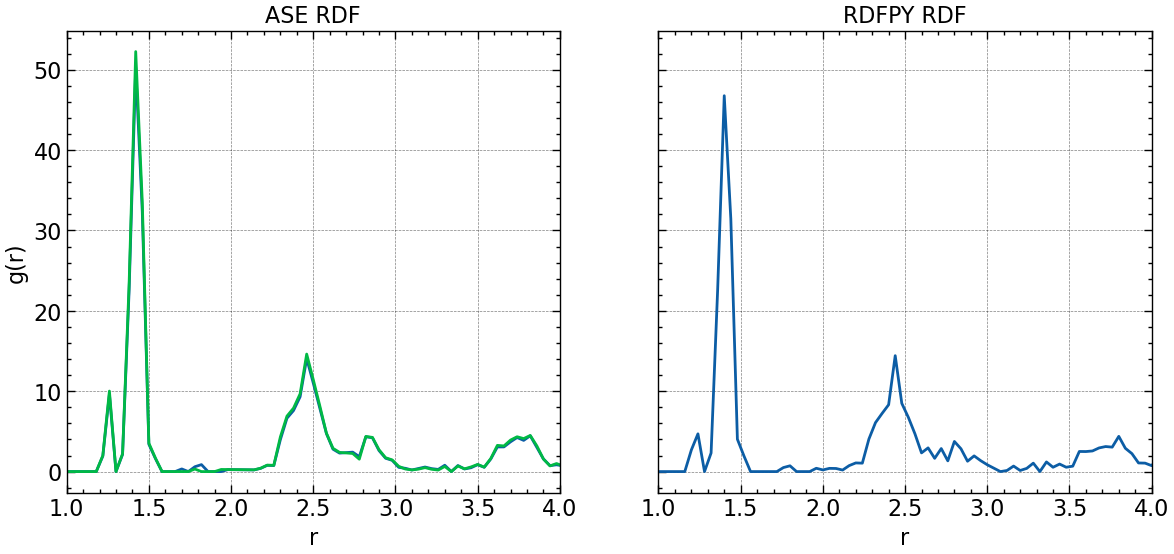

In [20]:
# Cl from EMiC with nanoscroll

plt.style.use(['science','notebook','grid'])

fig, ax = plt.subplots(1,2, figsize = (14,6), sharex=True, sharey=True)

# Con ase

from ase.geometry.analysis import get_rdf

a = get_rdf(all_atoms[-1][np.concatenate((cl_idx_from_EMiC,c_idx_nanoscroll))], 8,200)
ax[0].plot(a[1],a[0])
ax[0].set_title("ASE RDF")
ax[0].set_xlabel("r")
ax[0].set_ylabel("g(r)")

ax[0].set_xlim(1,4)


b = get_rdf(all_atoms[-1][np.concatenate((al_idx_from_alcl3,c_idx_nanoscroll))], 8,200)
ax[0].plot(b[1],b[0])


# Recomendado de Tomas
from rdfpy import rdf
gr, radii = rdf(all_atoms[-1][np.concatenate((cl_idx_from_EMiC,c_idx_nanoscroll))].get_positions(), dr = 0.04)


ax[1].plot(radii, gr)
ax[1].set_title("RDFPY RDF")
ax[1].set_xlabel("r")

In [21]:
a = read("/home/hernan-barquero/Desktop/Codigos/PhiS/Computational_Material_Science/carbon_nanoscrolls/t10_interface/last_converged/1-Ethyl-3-methylimidazolium_chloride_opt.xyz")
view(a)

<Popen: returncode: None args: ['/home/hernan-barquero/anaconda3/envs/genera...>

In [30]:
all_atoms[-1]

Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointDFTCalculator(...))

Text(0.5, 0, 'r')

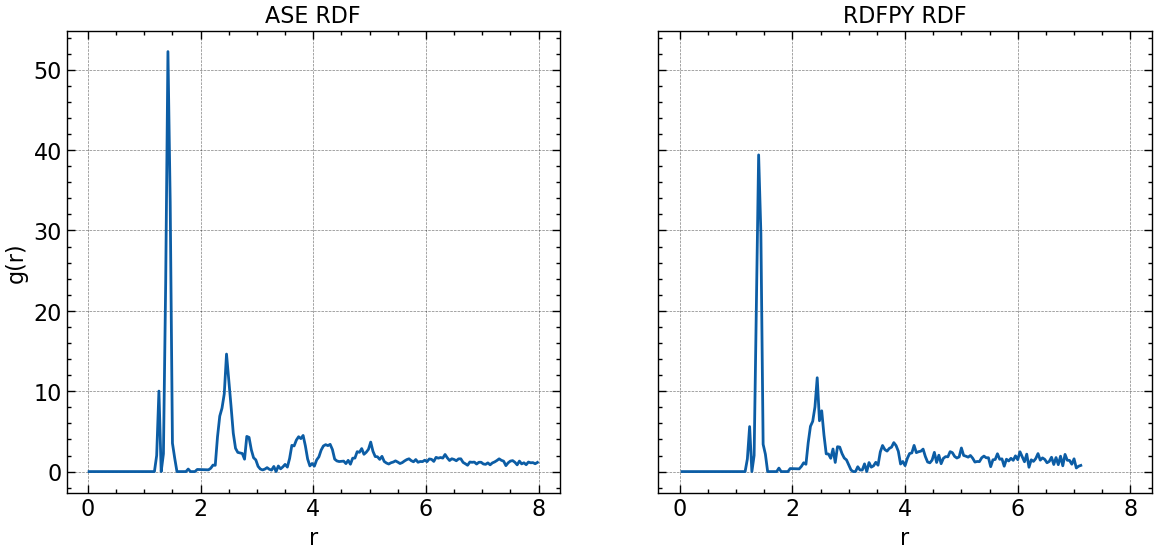

In [28]:
# Al from AlCl3 with nanoscroll

plt.style.use(['science','notebook','grid'])

fig, ax = plt.subplots(1,2, figsize = (14,6), sharex=True, sharey=True)

# Con ase

from ase.geometry.analysis import get_rdf

a = get_rdf(all_atoms[-1][np.concatenate((al_idx_from_alcl3,c_idx_nanoscroll))], 8,200)
ax[0].plot(a[1],a[0])
ax[0].set_title("ASE RDF")
ax[0].set_xlabel("r")
ax[0].set_ylabel("g(r)")


# Recomendado de Tomas
from rdfpy import rdf
gr, radii = rdf(all_atoms[-1][np.concatenate((al_idx_from_alcl3,c_idx_nanoscroll))].get_positions(), dr = 0.04)


ax[1].plot(radii, gr)
ax[1].set_title("RDFPY RDF")
ax[1].set_xlabel("r")

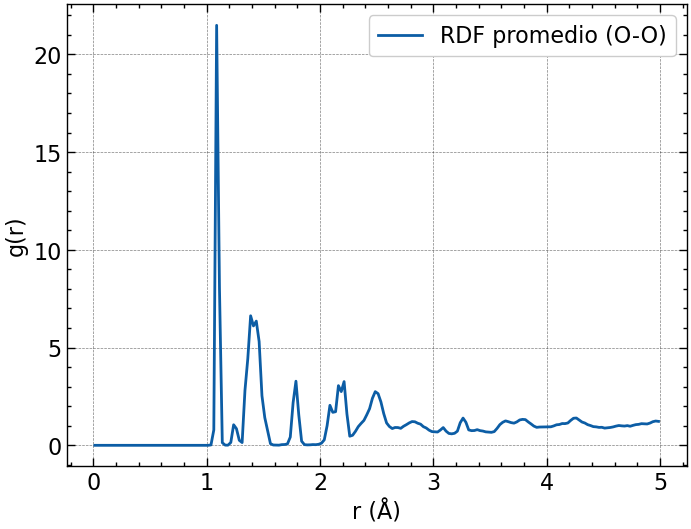

In [35]:
from ase.io import read
from ase.geometry.rdf import get_rdf
from ase.data import atomic_numbers
import numpy as np
import matplotlib.pyplot as plt

# lee todos los frames
frames = all_atoms

rmax = 5.0
nbins = 200

sum_rdf = None
nframes = len(frames)

# Si quieres un RDF parcial entre elementos, convierte símbolos a números atómicos:
# ej. para O-O
elems = ('O', 'O')
elements = (atomic_numbers[elems[0]], atomic_numbers[elems[1]])

for atoms in frames:
    # IMPORTANT: asegúrate de que la celda y PBC estén definidas correctamente en cada frame
    # get_rdf devuelve (rdf, distances) si no usas no_dists=True
    rdf, r = get_rdf(atoms, rmax, nbins)  # elements=None para total
    if sum_rdf is None:
        sum_rdf = np.array(rdf, dtype=float)
    else:
        sum_rdf += np.array(rdf, dtype=float)

avg_rdf = sum_rdf / nframes

plt.plot(r, avg_rdf, label=f'RDF promedio ({elems[0]}-{elems[1]})')
plt.xlabel('r (Å)')
plt.ylabel('g(r)')
plt.legend()
plt.show()
